**Data Cleaning & Visualization Project**

**Objective:**
To clean, process, and analyze a student exam dataset and extract meaningful insights using visualization.

**Dataset:**
This dataset contains information about students’ academic performance in three core subjects: mathematics, reading, and writing. It also includes demographic and socio-economic attributes such as gender, parental level of education, type of lunch, and test preparation status.

The dataset is commonly used for data analysis and visualization to understand how different factors influence student performance.

Dataset Size
Number of Records: 1000 students
Number of Features: 8 columns

In [1]:
from google.colab import files
uploaded = files.upload()

Saving exams.csv to exams (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("exams.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,66.396000,69.002000,67.738000
std,15.402871,14.737272,15.600985
min,13.000000,27.000000,23.000000
25%,56.000000,60.000000,58.000000
50%,66.500000,70.000000,68.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


**Data Overview:**
- Dataset contains 1000 student records
- Includes both categorical and numerical features
- Scores range from low to high, showing diverse student performance

In [7]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [10]:
df.duplicated().sum()

np.int64(1)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [14]:
df.fillna(df.mean(numeric_only=True), inplace=True)

No missing values were found, so no imputation was required.

In [15]:
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

**Data Cleaning Steps:**
- Checked for missing values (no missing values found)
- Removed duplicate records
- Renamed columns for consistency
- Prepared dataset for analysis

In [16]:
df['average_score'] = (df['math_score'] + df['reading_score'] + df['writing_score']) / 3
df.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,male,group A,high school,standard,completed,67,67,63,65.666667
1,female,group D,some high school,free/reduced,none,40,59,55,51.333333
2,male,group E,some college,free/reduced,none,59,60,50,56.333333
3,male,group B,high school,standard,none,77,78,68,74.333333
4,male,group E,associate's degree,standard,completed,78,73,68,73.000000


**Feature Engineering:**
A new column `average_score` was created to represent overall student performance.

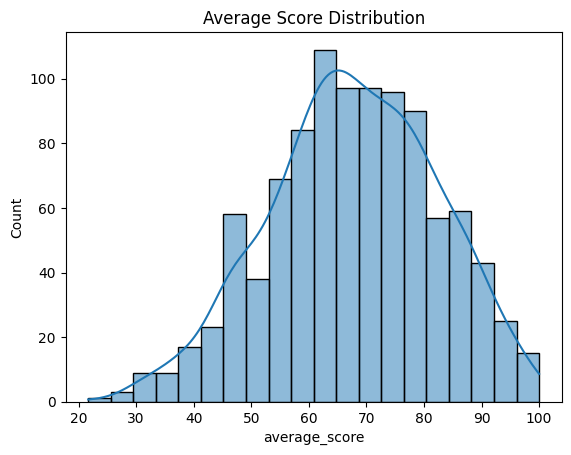

In [17]:
sns.histplot(df['average_score'], kde=True)
plt.title("Average Score Distribution")
plt.show()

**Insight:**
Most students scored between 60 and 80, showing a normal distribution of performance.



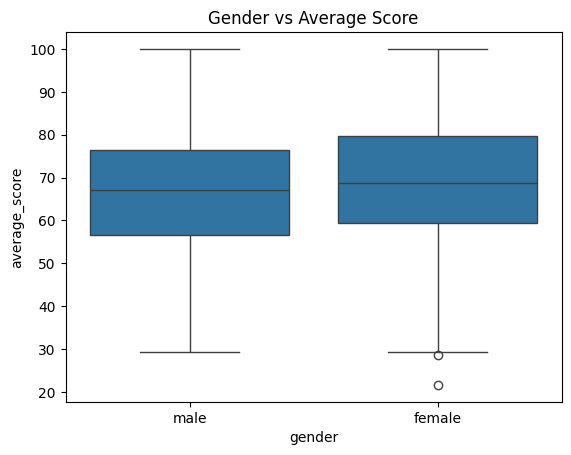

In [18]:
sns.boxplot(x='gender', y='average_score', data=df)
plt.title("Gender vs Average Score")
plt.show()

**Insight:**
Female students show slightly higher median scores compared to male students.

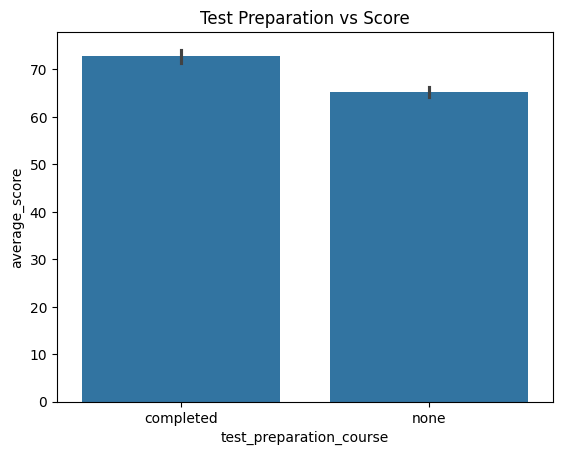

In [19]:
sns.barplot(x='test_preparation_course', y='average_score', data=df)
plt.title("Test Preparation vs Score")
plt.show()

**Insight:**
Students who completed the test preparation course performed better than those who did not.

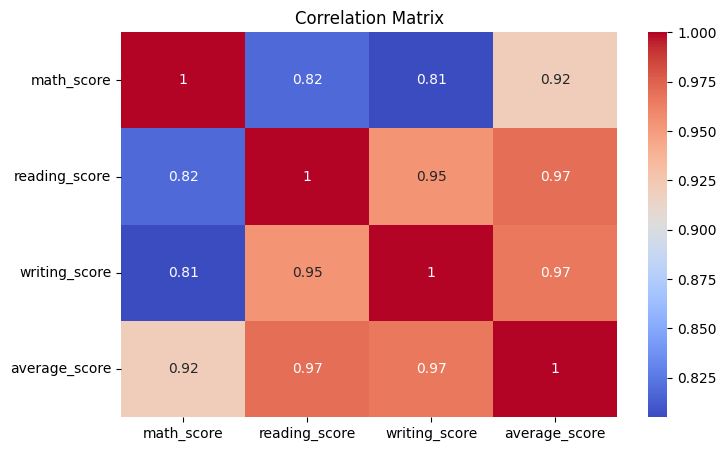

In [20]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Insight:**
Math, reading, and writing scores are strongly correlated with each other.

In [21]:
Q1 = df['average_score'].quantile(0.25)
Q3 = df['average_score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['average_score'] < lower_bound) | (df['average_score'] > upper_bound)]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 2


**Outlier Detection:**
The IQR method was used to detect outliers. Only a small number of outliers were found, so no data was removed.

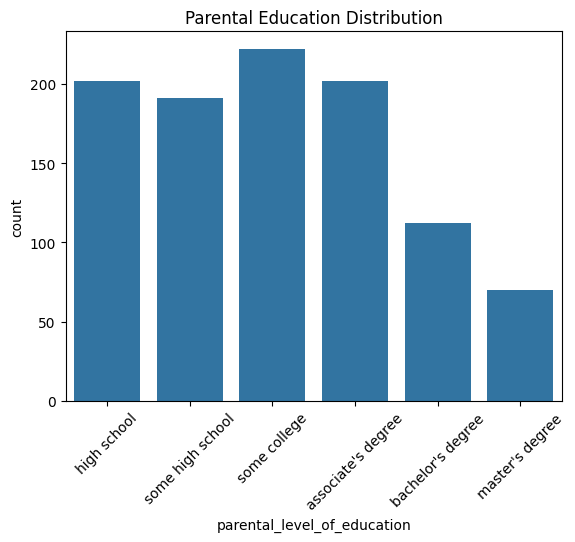

In [22]:
sns.countplot(x='parental_level_of_education', data=df)
plt.xticks(rotation=45)
plt.title("Parental Education Distribution")
plt.show()

**Insight:** Students come from various parental education backgrounds, with many having high school or some college education.

**Conclusion:**

- Most students scored in the average range (60–80)
- Test preparation has a positive impact on performance
- Female students slightly outperform male students
- Scores across subjects are highly correlated
- Data cleaning ensured reliable and accurate results

**Final Note:**
This project demonstrates how data preprocessing and visualization can uncover meaningful insights from raw data.